In [ ]:
import os
import sys

import collections
import xarray as xr
xr.set_options(keep_attrs=True)
import netCDF4 as nc
import numpy as np
np.seterr(divide='ignore', invalid='ignore')
import metpy.calc as mp
from metpy.units import units
from scipy.stats import ttest_ind, ttest_rel
from datetime import datetime

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import cmocean.cm as cmo

# settings
%config InlineBackend.figure_format = 'retina'

In [13]:
### +++ LOAD DATA +++ ###

# set file info
dpath0='../topo_files' # top level data directory
files={ 'etopo':{}, 'ctrl':{}, 'max':{}, 'p85':{}, 'p80':{}, '1.5env':{}, '1env':{} }

files['etopo'] = f'{dpath0}/obs.etopo5.zsurf.nc'
files['ctrl'] = f'{dpath0}/e2pt1.ctrl.zsurf.nc'
files['max'] = f'{dpath0}/e2pt1.max.global.zsurf.nc'
files['p85'] = f'{dpath0}/e2pt1.85p.ca-sa.zsurf.nc'
files['p80'] = f'{dpath0}/e2pt1.80p.ca-sa.zsurf.nc'
files['1.5env'] = f'{dpath0}/e2pt1.1pt5sEnv.ca-sa.zsurf.nc'
files['1env'] = f'{dpath0}/e2pt1.1sEnv.ca-sa.zsurf.nc'

# init dictionary
topo={ 'etopo':{}, 'ctrl':{}, 'max':{}, 'p85':{}, 'p80':{}, '1.5env':{}, '1env':{} }

for key in files.keys():
    
    # need to process the etopo data first
    if key in ['etopo']:
        etopo_full = xr.open_dataset(files[key]).ROSE
        # rename dimensions to match model data
        etopo_full = etopo_full.rename({'ETOPO05_Y':'lat', 'ETOPO05_X':'lon'}) 
        # switch from 0:360 to -180:180 lons
        nx = len(etopo_full.lon)
        lons = np.linspace(-180,180,nx)
        etopo_full['lon']=lons
        etopo_full=etopo_full.roll(lon=2160)
        topo[key] = etopo_full.where(etopo_full>0,np.nan) # remove bathymetry
    else:
        topo[key] = xr.open_dataset(files[key]).zatmo

# read in land mask from default surface boundary condition file
land_mask = xr.open_dataset(files[key]).fgrnd

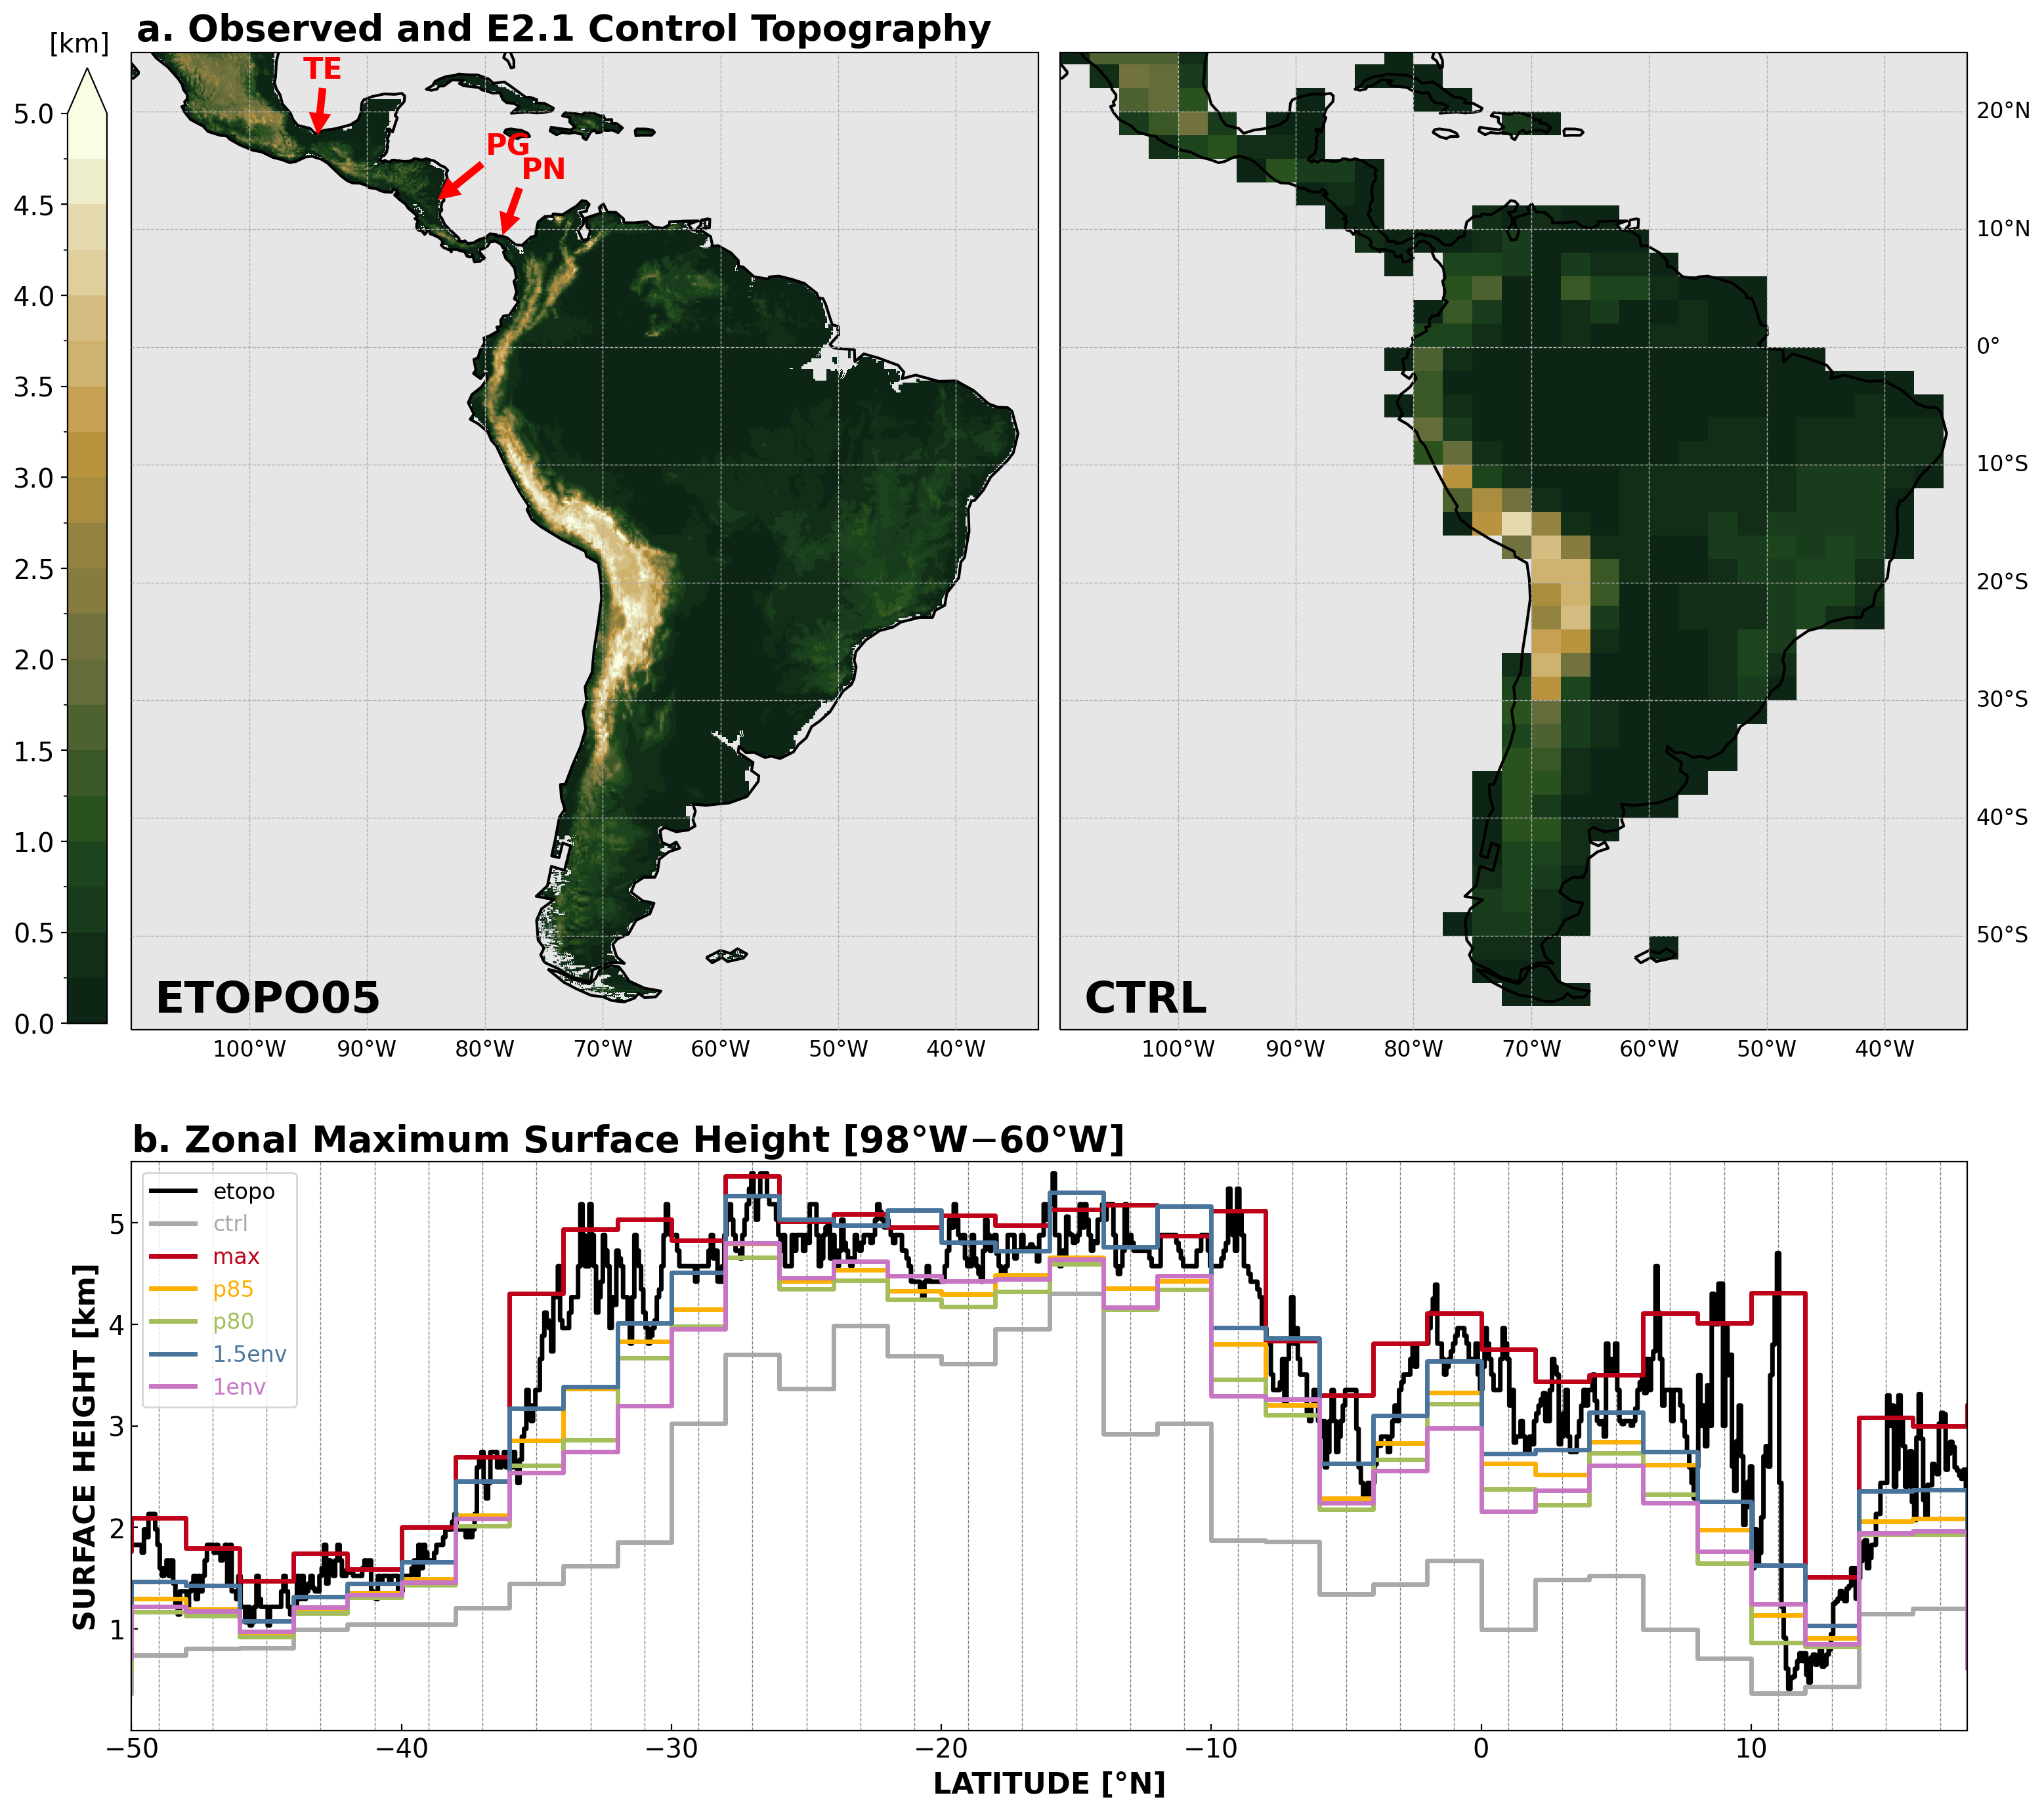

In [21]:
colors=['black','darkgray','#be0119','#fcb001','#a4be5c','#49759c','#c875c4'] # for histograms
tkw = {'axis': 'both', 'direction':'in', 'labelsize': 'x-large', 'labelcolor': 'k'}   
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'left'}
ax_text_kw={'color':'k', 'weight':'bold', 'size':16, 'ha':'center'}
font={'color':  'k', 'weight': 'bold', 'size':24, 'horizontalalignment': 'left'}
arrow_kw={'color':'red', 'linewidth':.1, 'shrink':0}
arr_text_kw={'color':'r', 'weight':'bold', 'size':16, 'ha':'center', 'va':'center'}
line_kw={'ls':'-', 'lw':2.5, 'drawstyle':'steps-mid'} 
legend_kw={'fontsize':'large', 'ncols':1, 'labelcolor':'linecolor', 'frameon':True}

# colormap specs
cmap_full=cmo.topo
cmap=ListedColormap(cmap_full(np.linspace(0.5, 1)))
levels=np.linspace(0,5,21)
norm=mpl.colors.BoundaryNorm(levels, cmap.N)

# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds = [-110., -33., -58., 25.]

# make fig
fig=plt.figure(figsize=(15,14), layout='constrained')
fig.text(0.035, .96, 'a. Observed and E2.1 Control Topography', **text_kw)

# ETOPO05 Topography
ax=plt.subplot2grid((3, 4), (0, 0), colspan=2, rowspan=2, projection=proj)
ax.text(-108, -56.5, 'ETOPO05', **font, zorder=100)
ax.pcolormesh(topo['etopo'].lon, topo['etopo'].lat, topo['etopo']/1000, cmap=cmap, norm=norm, transform=trans, zorder=2)
ax.coastlines(zorder=4, linewidth=1.5, color='k')
ax.add_feature(cfeature.OCEAN, fc=(0.9, 0.9, 0.9), zorder=2)
ax.add_feature(cfeature.LAND, fc=(0.9, 0.9, 0.9), zorder=1)

ax.annotate('TE', xy=(-94.2, 18), xytext=(-93.75, 23.5), arrowprops=arrow_kw, **arr_text_kw, label='_Hidden', zorder=100)
ax.annotate('PG', xy=(-84, 12.5), xytext=(-78, 17), arrowprops=arrow_kw, **arr_text_kw, label='_Hidden', zorder=100)
ax.annotate('PN', xy=(-78.5, 9.5), xytext=(-75, 15), arrowprops=arrow_kw, **arr_text_kw, label='_Hidden', zorder=100)

ax.set_extent(map_bnds, crs=trans)
gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
gl.bottom_labels=True; gl.left_labels=False; gl.top_labels=False; gl.right_labels=False
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':12}
gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':12}
gl.xlocator=mticker.FixedLocator([-140,-130, -120, -110, -100, -90, -80, -70, -60, -50, -40, -30])
gl.ylocator=mticker.FixedLocator([-50,-40,-30,-20,-10,0,10,20])

# Model E2.1 Control Topography
ax=plt.subplot2grid((3, 4), (0, 2), colspan=2, rowspan=2, projection=proj)
ax.text(-108, -56.5, 'CTRL', fontdict=font, zorder=100)
cf=ax.pcolormesh(topo['ctrl'].lon, topo['ctrl'].lat, topo['ctrl'].where(land_mask>0.1,np.nan)/1000, cmap=cmap, norm=norm, transform=trans, zorder=2)
ax.coastlines(zorder=3, linewidth=1.5, color='k')
ax.add_feature(cfeature.OCEAN, fc=(0.9, 0.9, 0.9), zorder=1)
ax.add_feature(cfeature.LAND, fc=(0.9, 0.9, 0.9), zorder=1)
ax.set_extent(map_bnds, crs=trans)
gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
gl.bottom_labels=True; gl.left_labels=False; gl.top_labels=False; gl.right_labels=True
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':12}
gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':12}
gl.xlocator=mticker.FixedLocator([-140,-130, -120, -110, -100, -90, -80, -70, -60, -50, -40, -30])
gl.ylocator=mticker.FixedLocator([-50,-40,-30,-20,-10,0,10,20])

cax=fig.add_axes([0, 0.425, 0.02, 0.52])
cf=mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar=fig.colorbar(cf, ticks=[0,0.5,1,1.5,2,2.5,3,3.5,4,4.5,5], orientation='vertical', extend='max', cax=cax)
cbar.set_label('[km]', y=1.09, labelpad=-15, rotation=0, size='x-large', ha='center')
cbar.ax.tick_params(labelsize='x-large')
cbar.ax.yaxis.set_ticks_position('left') 



## Zonal Mean Histograms
ax=plt.subplot2grid((3, 4), (2, 0), colspan=4, rowspan=1)
ax.text(-50, 5.7, 'b. Zonal Maximum Surface Height [98°W$-$60°W]', **text_kw)

# calculate and plot zonal maximum surface height
for i,key in enumerate(files.keys()):
    zonal_max = topo[key].sel(lat=slice(-55,20), lon=slice(-98,-60)).max(dim="lon",skipna=True)
    ax.plot(zonal_max.lat, zonal_max/1000, c=colors[i], label=key, **line_kw)
# set axis info
ax.set(xlim=[-50, 18], ylim=[0,5.6])
plt.yticks([1, 2, 3, 4, 5])
ax.set_xlabel('LATITUDE [°N]', **ax_text_kw)
ax.set_ylabel('SURFACE HEIGHT [km]', **ax_text_kw)
ax.tick_params(**tkw)
for j in zonal_max.lat[1::1]:
    ax.axvline(x=j,  c='gray', lw=.5, ls='--', zorder=0)
ax.legend(loc=2, **legend_kw) 
